In [2]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

Some notes about the state of the analysis:

1. There seems to be a decrease in V0 / [E] as a function of [E] after ~1-2 uM... why?? Check 
    1. baseline correction, 
    2. potential apparent reduction of velocity due to being too slow with the pipette,
2. The wt_dmso trail is a bit of a mess. Why? Investigate. It seems, though, that the V's are ~2x higher

* work on more robust automatic linear fitting
* should we propogate error in the fitting of MM parameters?

In [13]:
# choose the data to analyze

mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'g', 'orange']

ks_s = [
        KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt'),
        KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A'),
        KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A'),
        KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A'),
       ]

#    ks = KineticsSeries('./wt_dmso/wt_dmso.yaml', corrections='./config.yaml', prefix='./wt_dmso')

ps = [2.0, 5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
Loading: 210427_40_20_and_10µM_MproN214A.csv...
 ... excluding E=20.00 / S=20.00
 ... excluding E=10.00 / S=20.00
Loading: 210427_5_

In [14]:
n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

for ks in ks_s:
    ks.fit_v0(r2_threshold=0.0, regions=16)

7 6


S284A


<IPython.core.display.Javascript object>


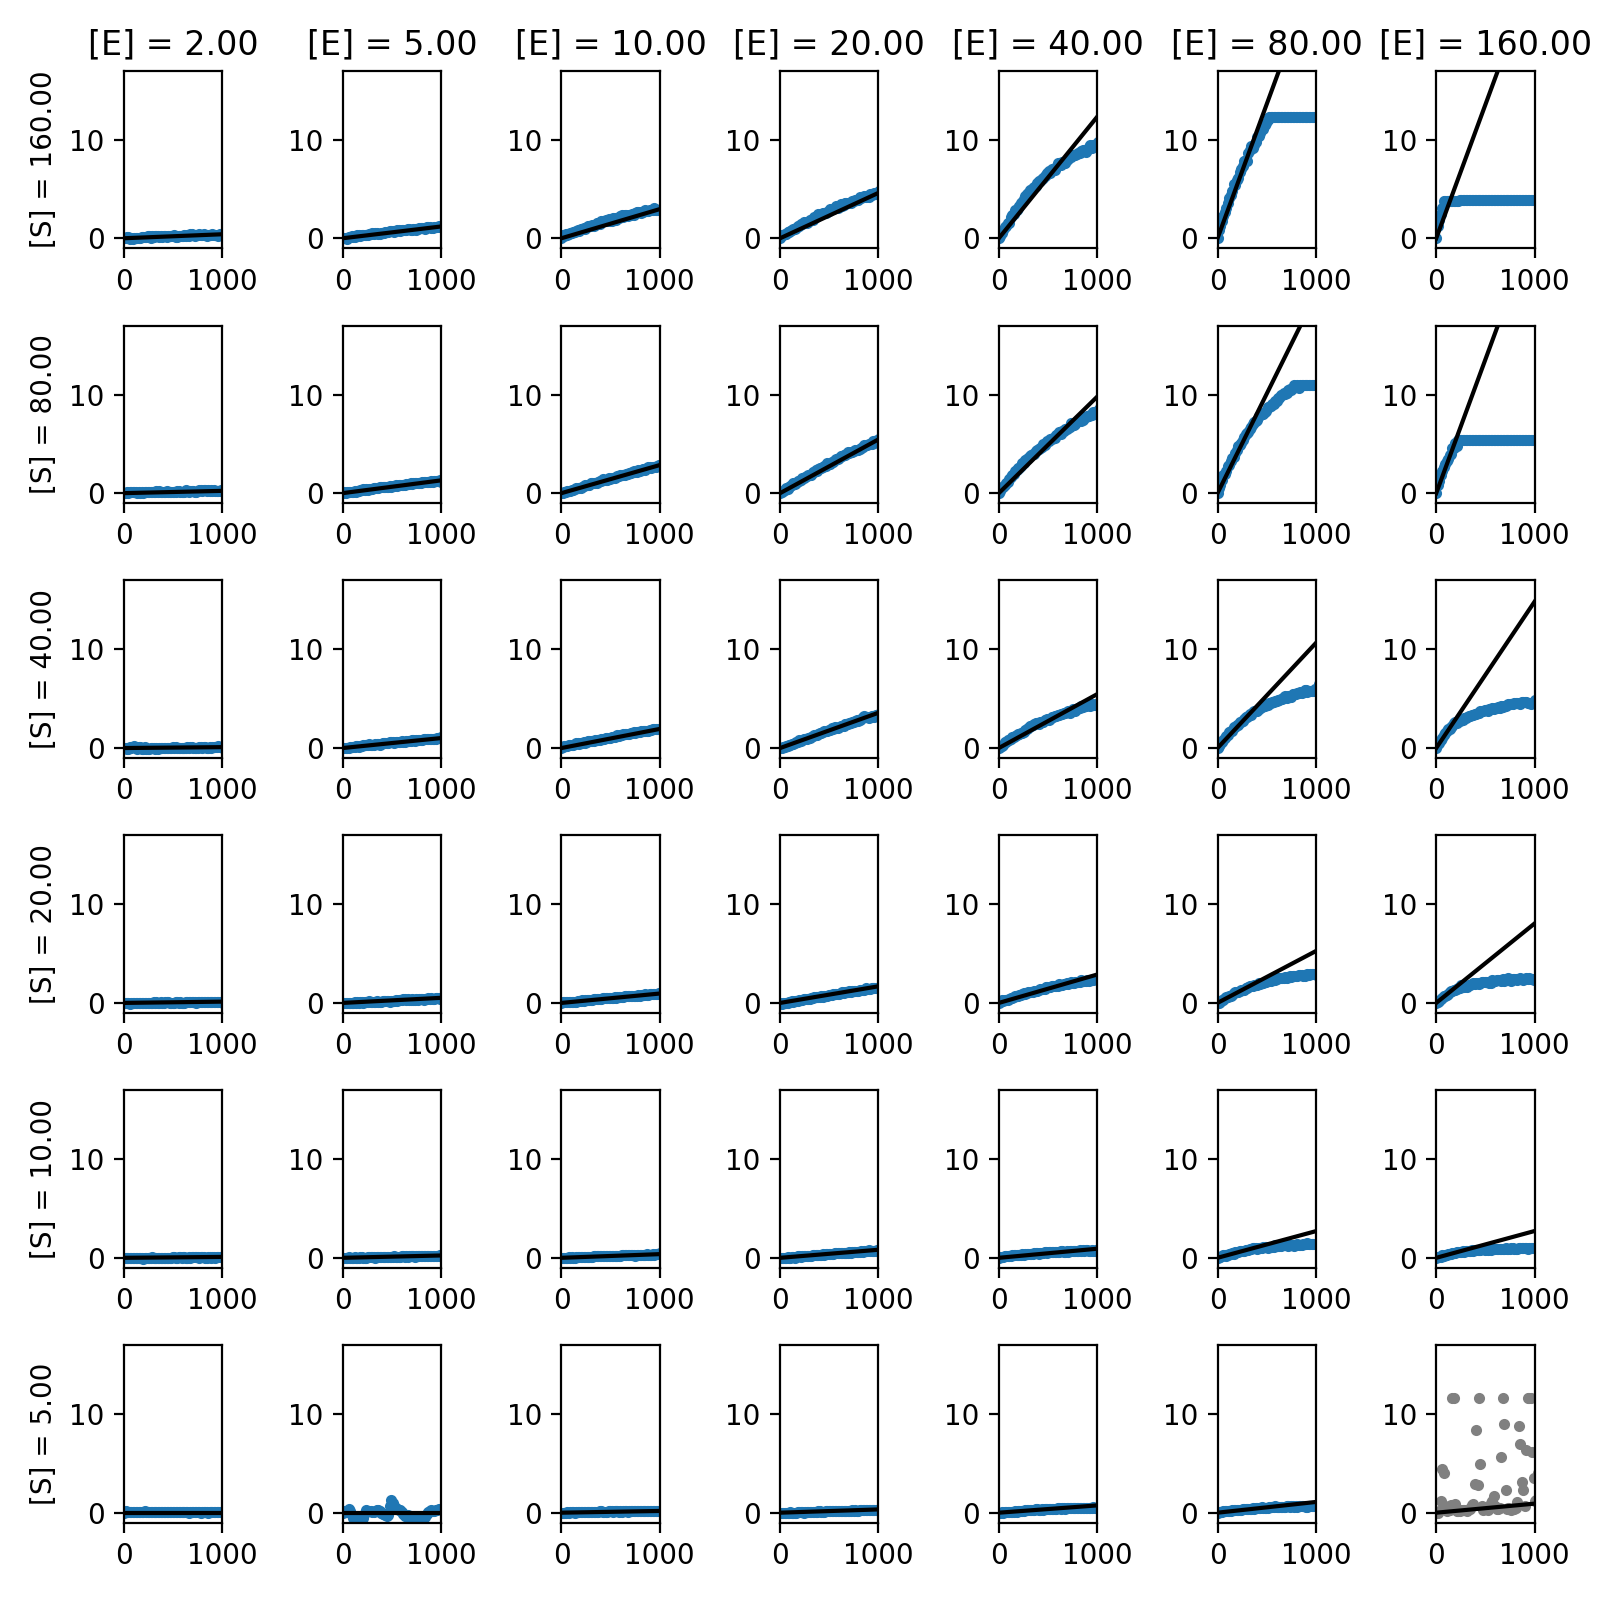

excluded: p=160.000000 / s=5.000000


In [20]:
# choose one mutant and inspect

mutant_index = 3
mutant = mutants[mutant_index]
print(mutant)

ks = ks_s[mutant_index]

fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 1000])
            axes[i_s, i_p].set_ylim([-1, 17])
            
            if entry['exclude']:
                axes[i_s, i_p].plot(t, entry['timeseries'], '.', color='gray')
                axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
                print('excluded: p=%f / s=%f' % (p, s))
                continue
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
            
plt.tight_layout()
plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

## Fit all mutants

In [16]:
# capture the k_cat, K_m for each mutant
# (mutants, protein_concentrations, conc/k_cat/k_cat_err/K_m/K_m_err)

kinetic_params = np.zeros([4, n_p, 5])

<IPython.core.display.Javascript object>


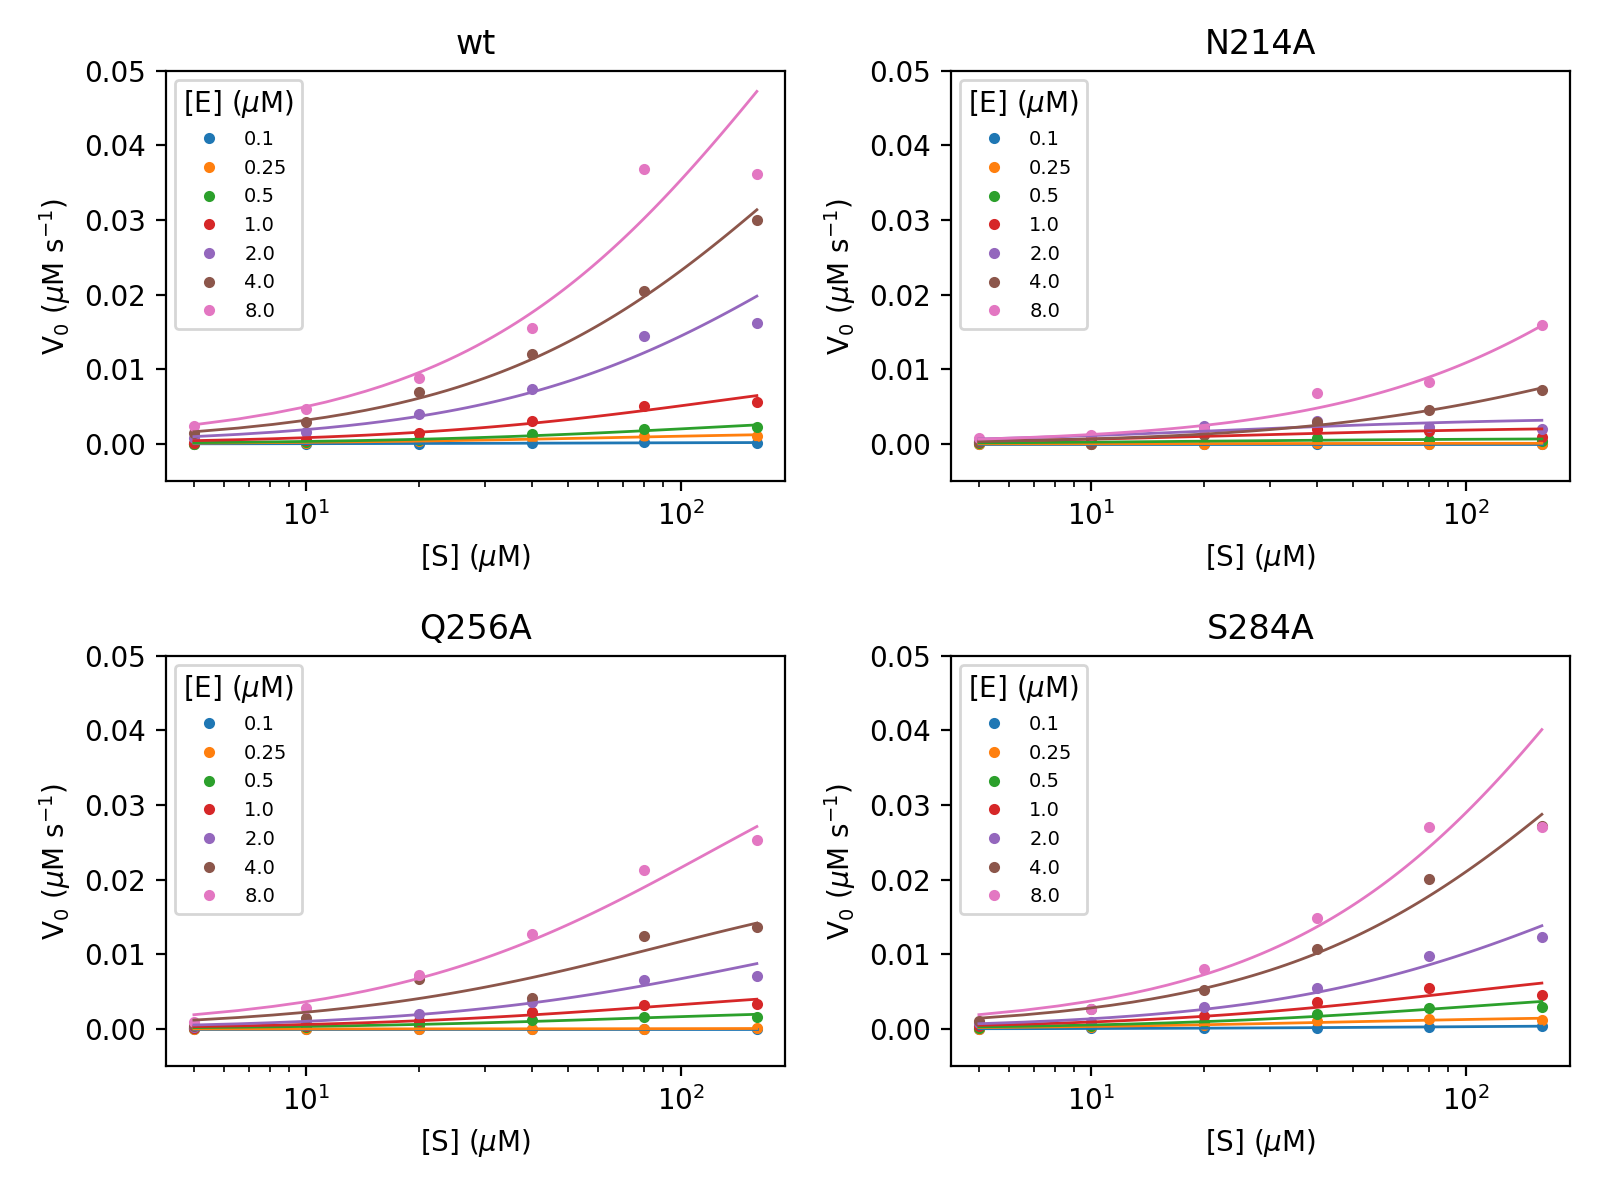


---wt---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.10	2.54e-03	5.11e-04	6.21e+01	2.38e+01
0.25	7.16e-03	2.73e-04	7.30e+01	4.70e+00
0.50	9.12e-03	2.45e-04	1.26e+02	5.39e+00
1.00	1.17e-02	1.69e-04	1.29e+02	2.79e+00
2.00	2.60e-02	1.57e-03	2.61e+02	1.91e+01
4.00	1.91e-02	1.46e-03	2.29e+02	2.15e+01
8.00	1.35e-02	1.80e-03	2.05e+02	3.46e+01

---N214A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.10	-5.28e-172	inf	1.00e+00	inf
0.25	3.92e-04	1.16e-04	2.65e+01	1.66e+01
0.50	1.50e-03	6.48e-05	2.13e+01	2.03e+00
1.00	2.34e-03	5.97e-05	2.63e+01	1.06e+00
2.00	1.81e-03	4.33e-05	2.24e+01	1.03e+00
4.00	5.69e-03	8.26e-04	3.26e+02	5.87e+01
8.00	8.63e-03	3.20e-03	5.36e+02	2.27e+02

---Q256A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.10	-1.81e-190	inf	1.00e+00	inf
0.25	8.04e+03	2.54e+11	5.66e+09	1.79e+17
0.50	5.74e-03	1.84e-04	7.47e+01	3.92e+00
1.00	6.36e-03	1.46e-04	9.57e+01	3.27e+00
2.00	8.84e-03	3.16e-04	1.63e+02	7.85e+00
4.00	5.49e-03	1.34e-04	8.79e+01	3.51e+00
8.00	5.

/Users/TJ/opt/miniconda3/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

for im, m in enumerate(mutants):
    
    ks = ks_s[im]
    
    print('\n---' + m + '---\n')

    ax = axes[ im//2, im%2 ]
    ax.set_title(m)
    
    for p in ps:
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.plot(s0s, v0s, '.')

    ax.legend( np.array(ps) / 20.0, title='[E] ($\mu$M)', fontsize=7, loc=2)

    # fit
    print('[E]\tk_cat\t\terr\t\tK_m\t\terr')
    print('---\t-----\t\t---\t\t---\t\t---')

    ax.set_prop_cycle(None)
    for i,p in enumerate(ps):

        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)

        (k_cat, K_m), perr = fit_mm(v0s, s0s, p / 20.0, v0errs=v0errs)

        print('%.2f\t%.2e\t%.2e\t%.2e\t%.2e' % (p / 20.0, k_cat, perr[0], K_m, perr[1]))
        kinetic_params[im,i,:] = np.array([p, k_cat, perr[0], K_m, perr[1]])

        S = np.linspace(ss.min(), ss.max(), 100)
        V_fit = mm( p / 20.0, S, k_cat, K_m)
        ax.plot(S, V_fit, lw=1)
    
    ax.set_xscale('log')
    ax.set_ylim([-0.005, 0.05])
    ax.set_xlabel('[S] ($\mu$M)')
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    
plt.tight_layout()
plt.savefig('figures/mm.pdf')
plt.show()

<IPython.core.display.Javascript object>


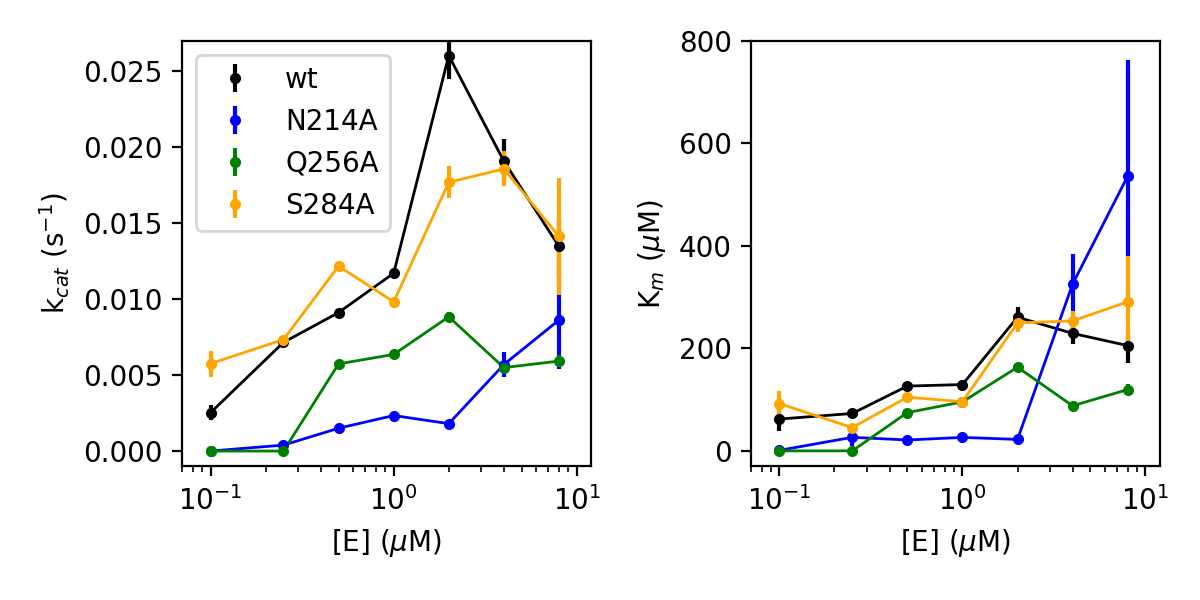

In [18]:
# by fiat, set Q256A E=0.1,0.25 values to zero (unmeasurable)
kinetic_params[2,0,1:] = 0.0
kinetic_params[2,1,1:] = 0.0

kinetic_params[1,0,4] = 0.0
# -----

plt.figure(figsize=(6,3))

plt.subplot(121)
for im, m in enumerate(mutants):
    plt.errorbar(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,1], fmt='.',
                 yerr=kinetic_params[im,:,2],
                 color=mutant_colors[im])
    plt.plot(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,1], 
             '-', color=mutant_colors[im], lw=1, label='_nolegend_')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')
plt.xscale('log')
plt.ylim([-0.001, 0.027])
plt.xlim([0.07, 12.0])
plt.legend(mutants)

plt.subplot(122)
for im, m in enumerate(mutants):
    plt.errorbar(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,3], fmt='.',
                 yerr=kinetic_params[im,:,4],
                 color=mutant_colors[im])
    plt.plot(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,3], 
             '-', color=mutant_colors[im], lw=1, label='_nolegend_')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M)')
plt.xscale('log')
plt.ylim([-30, 800])
plt.xlim([0.07, 12.0])
#plt.legend(mutants)

plt.tight_layout()
plt.savefig('figures/mm_parameters.pdf')
plt.show()